# Tutorial: Milestone 1 - Real MIntRec Text-Only Baseline

Audience:
- You've completed Milestone 0 (toy 8-class data) and the Milestone 1 transformer sanity check.
  This notebook is the real Milestone 1 goal from `CLAUDE.md`: reproduce text-only classification on
  the **actual MIntRec dataset**, not the bundled sample.

Prerequisites:
- Milestone 0 concepts: sample, feature, label, train/val/test, accuracy, macro-F1, confusion matrix.

Learning goals:
- By the end, you can explain how real, imbalanced, ambiguous data behaves differently from a tidy toy
  dataset, and read a 20-class classification report and confusion matrix.

**Data provenance:** text + label columns extracted from the official MIntRec dataset (Zhang et al.,
*MIntRec: A New Dataset for Multimodal Intent Recognition*, ACM MM 2022; [thuiar/MIntRec](https://github.com/thuiar/MIntRec)),
mirrored on Hugging Face as `THU-IAR/MIntRec` (license CC-BY-SA-4.0). We only use the small `all.tsv` text
file (127KB) -- the real dataset's raw video/audio clips are much larger and are **not** downloaded here;
that's Milestone 2+ territory.


## Outline

1. Setup
2. Step 1 - Load the real data and see how it differs from the toy dataset
3. Step 2 - Split into train / validation / test
4. Step 3 - Train the same TF-IDF + Logistic Regression baseline as Milestone 0
5. Step 4 - Evaluate: accuracy, macro-F1, per-class report, confusion matrix heatmap
6. Compare against the toy-dataset baseline
7. Look at the mistakes
8. Exercises
9. Pitfalls and extensions


In [1]:
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_PATH = PROJECT_ROOT / "data" / "mintrec" / "all.tsv"
RESULTS_DIR = PROJECT_ROOT / "results"
DATA_PATH


WindowsPath('c:/Users/dbest/Downloads/multimodal-intent-inference/multimodal-intent-inference/data/mintrec/all.tsv')

## Step 1 - Load the real data

Same idea as Milestone 0's `load_data()`, but this file is **tab-separated** (`.tsv`) and has extra columns
(`season`, `episode`, `clip`) identifying which TV episode and video segment each line of dialogue came
from -- a reminder that this text was originally spoken, not written in isolation.


In [2]:
df = pd.read_csv(DATA_PATH, sep="\t")
print(f"Loaded {len(df)} samples from {DATA_PATH.name}")
print(f"Columns: {list(df.columns)}")
print(f"Number of distinct intent classes: {df['label'].nunique()}")
df["label"].value_counts()


Loaded 2224 samples from all.tsv
Columns: ['season', 'episode', 'clip', 'text', 'label']
Number of distinct intent classes: 20


label
Complain        286
Inform          284
Praise          213
Apologise       136
Thank           124
Advise          122
Criticize       117
Arrange         110
Introduce       105
Care             95
Comfort          88
Leave            85
Prevent          73
Taunt            62
Greet            60
Agree            59
Flaunt           52
Oppose           51
Ask for help     51
Joke             51
Name: count, dtype: int64

In [3]:
df[["text", "label"]].sample(5, random_state=0)


,text,label
384,"thank you for those kind words, jonah.",Thank
1982,i think i voted wrong!,Complain
985,it really is gorgeous.,Praise
1386,"but one day, i got it to do 25.",Flaunt
1294,"oh, don't do that.",Prevent


**Interpretation:** this is a completely different shape of problem from Milestone 0. Instead of 96 rows
split evenly across 8 made-up classes, we have 2,224 real lines of TV dialogue across **20** classes with
real imbalance -- `Complain` has 286 examples, `Joke` and `Ask for help` have about 51 each. Real-world data
is almost never as tidy as a toy dataset, and that imbalance is exactly what macro-F1 exists to expose.


## Step 2 - Split into train / validation / test

Same stratified split logic as Milestone 0 -- even the rarest class (~51 rows) still gets a proportional
share of train/val/test.


In [4]:
train_val, test = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df["label"]
)
train, val = train_test_split(
    train_val, test_size=0.1875, random_state=42, stratify=train_val["label"]
)

print(f"train: {len(train)} samples  (model learns from these)")
print(f"val:   {len(val)} samples  (reserved for tuning)")
print(f"test:  {len(test)} samples  (final honest judgement)")


train: 1445 samples  (model learns from these)
val:   334 samples  (reserved for tuning)
test:  445 samples  (final honest judgement)


## Step 3 - Train the same TF-IDF + Logistic Regression baseline

Identical model to Milestone 0 -- the point of this notebook is to see how the *same* simple pipeline
behaves on real data, not to build a fancier model yet.


In [5]:
model = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
        ("clf", LogisticRegression(max_iter=1000)),
    ]
)
model.fit(train["text"], train["label"])

n_features = len(model.named_steps["tfidf"].vocabulary_)
print(f"Training done. The model turned the text into {n_features} features (vs. 482 on the toy dataset).")


Training done. The model turned the text into 8018 features (vs. 482 on the toy dataset).


## Step 4 - Evaluate

With 20 classes, a text confusion matrix would be far too wide to read, so we plot it as a heatmap instead
of printing an ASCII table.


In [6]:
preds = model.predict(test["text"])
truth = test["label"].tolist()

acc = accuracy_score(truth, preds)
macro_f1 = f1_score(truth, preds, average="macro")
print(f"Accuracy : {acc:.3f}   (share of predictions that were exactly right)")
print(f"Macro-F1 : {macro_f1:.3f}   (fairer average across all 20 intents)")


Accuracy : 0.508   (share of predictions that were exactly right)
Macro-F1 : 0.409   (fairer average across all 20 intents)


In [7]:
print(classification_report(truth, preds, zero_division=0))


              precision    recall  f1-score   support

      Advise       0.64      0.28      0.39        25
       Agree       0.78      0.58      0.67        12
   Apologise       0.96      0.93      0.94        27
     Arrange       0.88      0.32      0.47        22
Ask for help       1.00      0.10      0.18        10
        Care       0.85      0.58      0.69        19
     Comfort       0.85      0.61      0.71        18
    Complain       0.34      0.77      0.47        57
   Criticize       0.50      0.13      0.21        23
      Flaunt       0.00      0.00      0.00        10
       Greet       0.71      0.42      0.53        12
      Inform       0.32      0.70      0.44        57
   Introduce       0.00      0.00      0.00        21
        Joke       0.00      0.00      0.00        10
       Leave       0.75      0.18      0.29        17
      Oppose       0.50      0.20      0.29        10
      Praise       0.59      0.74      0.66        43
     Prevent       0.50    

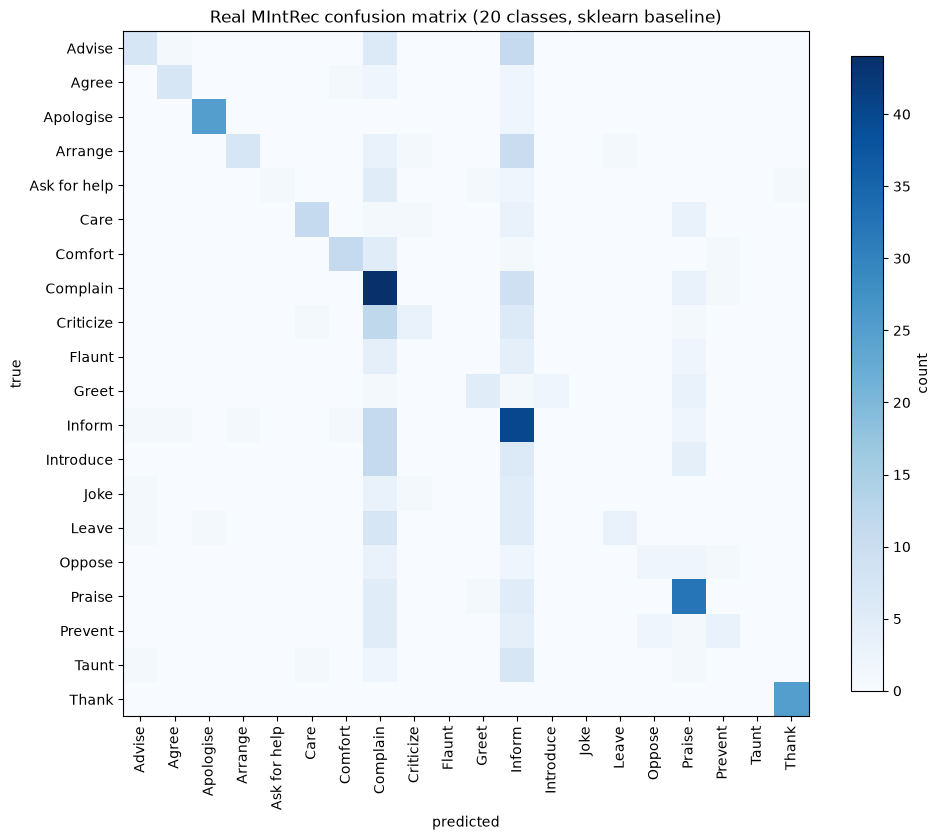

In [8]:
labels = sorted(test["label"].unique())
cm = confusion_matrix(truth, preds, labels=labels)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)), labels, rotation=90)
ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Real MIntRec confusion matrix (20 classes, sklearn baseline)")
fig.colorbar(im, ax=ax, shrink=0.8, label="count")
fig.tight_layout()
plt.show()


### Compare against the toy-dataset baseline (Milestone 0)


In [9]:
comparison = pd.DataFrame([
    {"dataset": "Toy sample (96 rows, 8 classes) - M0", "accuracy": 0.550, "macro_f1": 0.521},
    {"dataset": "Real MIntRec (2,224 rows, 20 classes) - M1", "accuracy": acc, "macro_f1": macro_f1},
]).set_index("dataset")
comparison


,accuracy,macro_f1
dataset,,
"Toy sample (96 rows, 8 classes) - M0",0.550000,0.521000
"Real MIntRec (2,224 rows, 20 classes) - M1",0.507865,0.409265


**Interpretation:** accuracy and macro-F1 both drop on the real dataset, but that's not simply "the model
got worse" -- it's a harder, more realistic problem: more than double the classes, genuine imbalance, and
ambiguous real dialogue (e.g. distinguishing `Complain` from `Criticize`, or `Inform` from `Introduce`) where
even a human might disagree with the label. Notice the classification report above: several rare classes
(`Flaunt`, `Introduce`, `Joke`, `Taunt`) scored **0** -- the model never predicted them correctly, likely
because they had too few training examples and/or overlap heavily in wording with more common classes.


## Look at the mistakes


In [10]:
results_df = pd.DataFrame({"text": test["text"], "true": truth, "predicted": preds})

RESULTS_DIR.mkdir(exist_ok=True)
out_path = RESULTS_DIR / "mintrec_predictions_sklearn.csv"
results_df.to_csv(out_path, index=False)
print(f"Saved every test prediction to {out_path.relative_to(PROJECT_ROOT)}")

mistakes = results_df[results_df["true"] != results_df["predicted"]]
print(f"\n{len(mistakes)} of {len(results_df)} test sentences were misclassified ({len(mistakes)/len(results_df):.1%}).")

# A few mistakes on the classes that scored 0, specifically -- these are the most informative to read.
mistakes[mistakes["true"].isin(["Flaunt", "Introduce", "Joke", "Taunt"])].head(10)


Saved every test prediction to results\mintrec_predictions_sklearn.csv

219 of 445 test sentences were misclassified (49.2%).


,text,true,predicted
558,it's the traditional last doll,Introduce,Complain
72,it's the business that we were gonna start.,Introduce,Inform
2162,i think i've won her over.,Flaunt,Complain
228,you look way too happy.,Taunt,Praise
207,"yeah, just traveling the world shirtless.",Joke,Complain
838,i was the best salesperson in the store.,Flaunt,Inform
1065,my jewish bird joke is so good,Flaunt,Praise
645,this is who we're visiting.,Introduce,Inform
1114,i hate you too.,Joke,Complain
1016,"hi, uh, i'm brian, by the way. i'm dina's boyf...",Introduce,Inform


## Exercises

1. Pick one of the 0-scoring classes above (e.g. `Joke`) and read a few of its misclassified rows. What did
   the model predict instead, and can you see why -- does the sentence *sound* like the wrong class out of
   context?
2. Try `ngram_range=(1, 1)` in the Step 3 cell (unigrams only) and rerun Steps 3-4. On the toy dataset this
   barely mattered; does it matter more here, with 8,018 features and much more text to learn from?


## Pitfalls and extensions

**Common mistake:** looking only at overall accuracy (0.5-ish) and concluding "the model is roughly a coin
flip." With 20 classes, random guessing would score about 0.05, not 0.5 -- so the model has clearly learned
real signal. The per-class report is what tells you *where* it's weak.

**Extension (bigger step, needs confirmation first):** rerun this with `--model transformer` via
`src/train_mintrec.py` to fine-tune DistilBERT on the real data instead of TF-IDF + Logistic Regression --
on the full 1,445-row training split this takes several minutes on CPU (not seconds), so per this project's
training-time rule, confirm with Claude Code before launching it rather than running it inline here.

**Extension (Milestone 2):** this notebook is text-only. The real MIntRec dataset also has aligned video and
audio for every segment -- adding those modalities is the next milestone in `CLAUDE.md`.
